In [1]:
%matplotlib notebook

In [2]:
from pathlib import Path
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import keras.utils.np_utils as np_utils
from simian_lstm.data import Dataset
from simian_lstm.model import Model
from simian_lstm.classifier import ModelClassifier

2023-09-06 13:51:39.734722: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-09-06 13:51:39.778837: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-09-06 13:51:40.481102: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/homes/jared/.local/lib/python3.8/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxve

In [3]:
def percentilePlot(
    arr,
    abs=False,
    log=False,
    label=None,
    xlabel="Percentile",
    ylabel=None,
    grid=True,
    yscale=None, # custom yscale object to use (argument to plt.yscale)
    transpose=False,
):
    if abs:
        arr = np.abs(arr)
    arr = np.sort(arr)
    percentiles = np.linspace(0, 100, len(arr))
    
    if not transpose:
        plt.plot(percentiles, arr, label=label)
    else:
        plt.plot(arr, percentiles, label=label)
        xlabel, ylabel = ylabel, xlabel
        
    if yscale:
        plt.yscale(scale)
    else:
        if log:
            if abs:
                plt.yscale("log")
            else:
                plt.yscale("symlog")
    if xlabel:
        plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)
        
        
        
    if grid:
        ax = plt.gca()
        ## from https://www.pythoncharts.com/matplotlib/customizing-grid-matplotlib/
        # Show the major grid and style it slightly.
        ax.grid(which='major', color='#DDDDDD', linewidth=0.8)
        # Show the minor grid as well. Style it in very light gray as a thin,
        # dotted line.
        ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=0.8)
        # Make the minor ticks and gridlines show.
        ax.minorticks_on()
    

In [4]:
infile_base_dir = Path(".") / "results" / "eval_steps"

infile_dir = infile_base_dir / "20230718-150704_windows-lstm_attack" # full attack set (~750)
trace_type = "attack"

# infile_dir = infile_base_dir / "20230718-145915_windows-lstm_test" # test set (first 1000)
# trace_type = "test"


model_type = "lstm"


exp_slug = f"{trace_type}_{model_type}"

infile = infile_dir / "results.txt"

In [5]:
fnames = []
likelihoods = []

with open(infile, 'r') as fin:
    for line in fin:
        splits = line.split()
        fname, *steps = splits
        steps = [float(x) for x in steps]
        steps = np.array(steps)
        likelihoods.append(steps)
        fnames.append(fname)

In [6]:
len(fnames)

1000

In [7]:
fnames[0]

'/homes/jared/projects/systemCalls/linux-lstm/simian_lstm/data/windows/attack/285_1280_3196.txt'

<IPython.core.display.Javascript object>


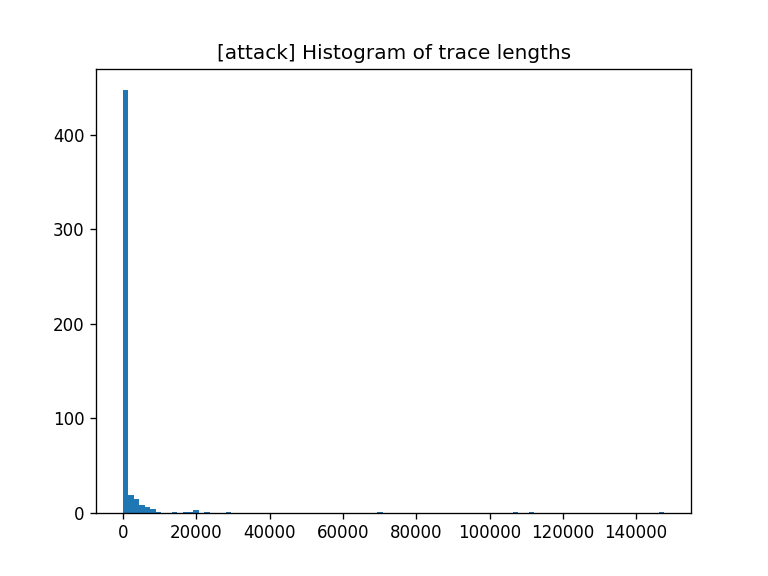

In [8]:
plt.figure("trace-lengths")
plt.title(f"[{trace_type}] Histogram of trace lengths")
arrs = likelihoods
arrs = [arr for arr in arrs if len(arr) > 1]
plt.hist([len(x) for x in arrs], bins=100)
plt.show()

<IPython.core.display.Javascript object>


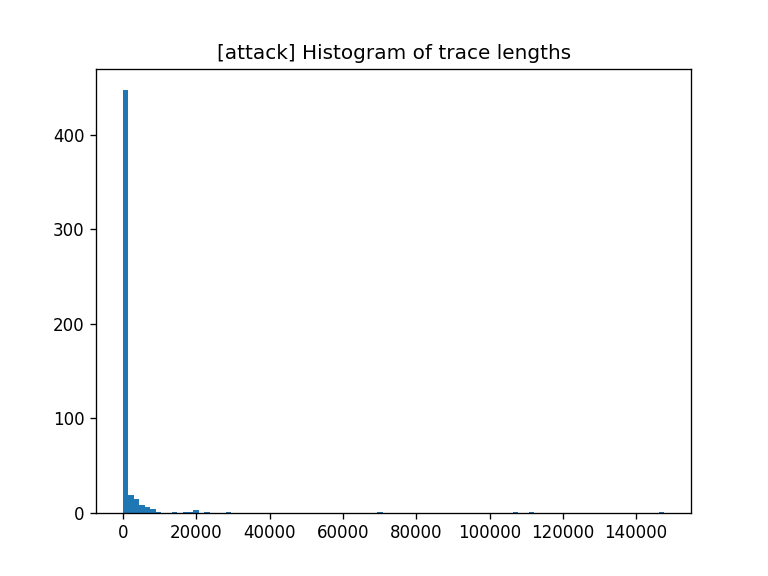

489


In [9]:
plt.figure("trace-lengths2")
plt.title(f"[{trace_type}] Histogram of trace lengths")
arrs = likelihoods
arrs = [arr for arr in arrs if len(arr) > 1]
print(len(likelihoods) - len(arrs))
bins=100
# bins = np.linspace(0, 1000, 100)
plt.hist([len(x) for x in arrs], bins=bins)
plt.show()

<IPython.core.display.Javascript object>


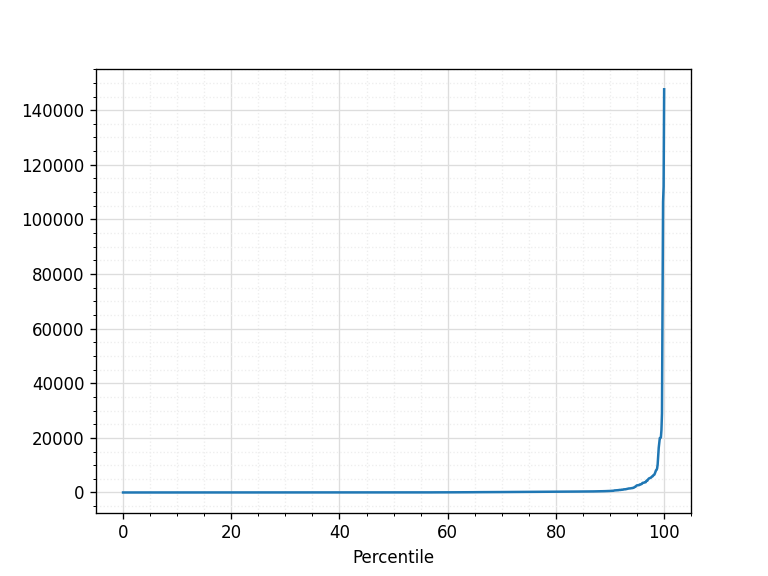

In [10]:
plt.figure("len-percentile")
percentilePlot([len(x) for x in likelihoods], transpose=False)
# plt.ylim(-50, 10000)
plt.show()

<IPython.core.display.Javascript object>


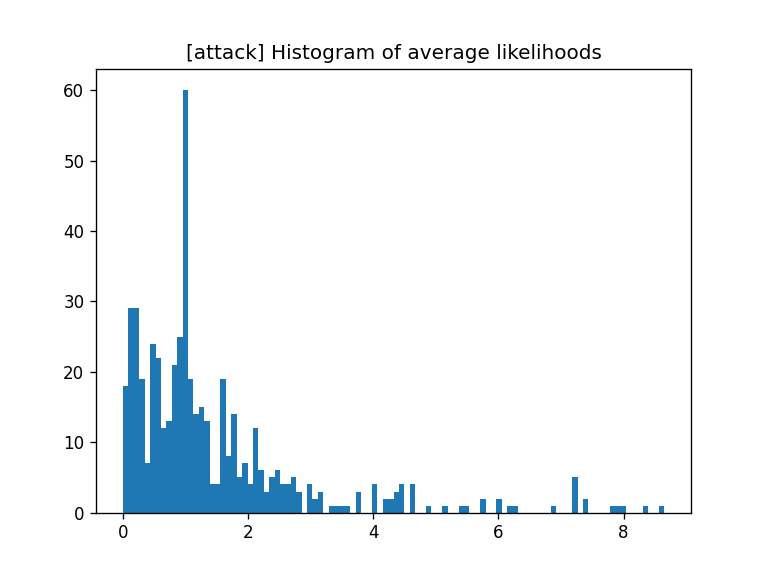

In [11]:
plt.figure("avg-likelihoods")
plt.title(f"[{trace_type}] Histogram of average likelihoods")
plt.hist([np.mean(x) for x in likelihoods if len(x) > 1], bins=100)
plt.show()

<IPython.core.display.Javascript object>


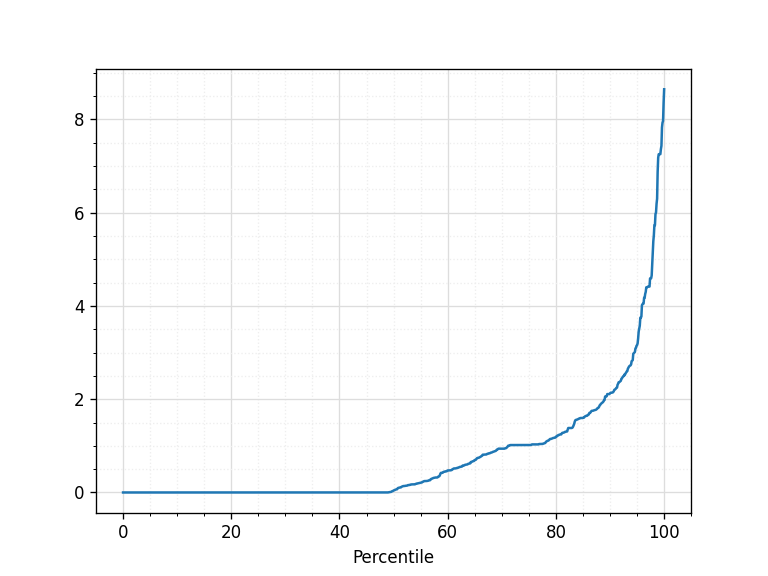

In [12]:
plt.figure("avg-lkhd-percentile")
percentilePlot([np.mean(x) for x in likelihoods])
plt.show()

<IPython.core.display.Javascript object>


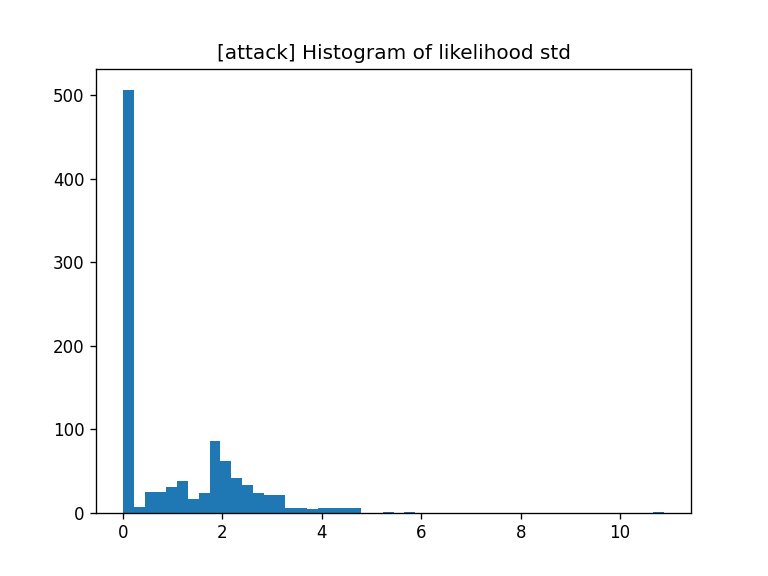

In [13]:
plt.figure("var-likelihoods")
plt.title(f"[{trace_type}] Histogram of likelihood std")
plt.hist([np.std(x) for x in likelihoods], bins=50)
plt.show()

<IPython.core.display.Javascript object>


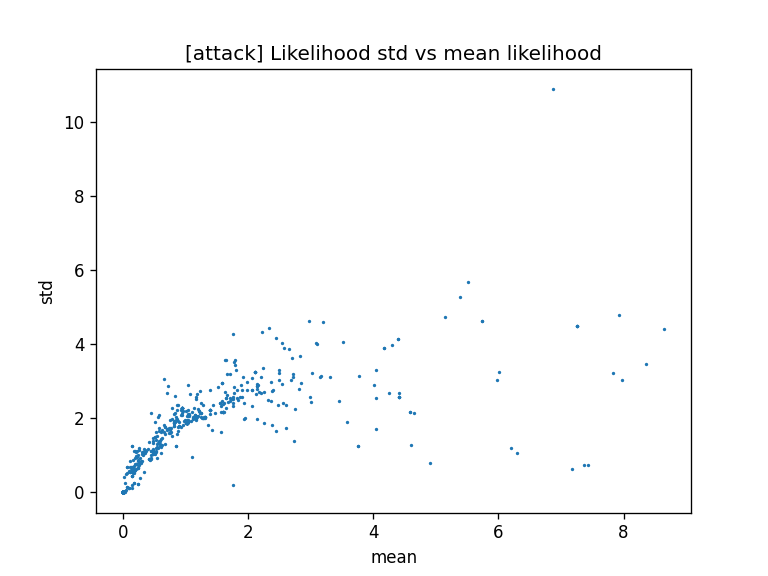

In [14]:
plt.figure("var-vs-mean")
plt.title(f"[{trace_type}] Likelihood std vs mean likelihood")
plt.xlabel("mean")
plt.ylabel("std")
# plt.xlim(0, 6)
# plt.ylim(0, 6)
plt.scatter([np.mean(x) for x in likelihoods], [np.std(x) for x in likelihoods], s=1)
plt.show()

In [15]:
def plot_sampled_step_likelihoods(
    thresh_low,
    thresh_high,
    nrows=4,
    ncols=4,
    seed=0,
    slug=None,
    remove_singletons=True,
    title_kwargs={},
    ):
    
    if slug is None:
        slug = exp_slug
    
    if thresh_high is None:
        mask = np.array([np.mean(arr) > thresh_low for arr in likelihoods])
        cmp_str = f"anomaly_score > {thresh_low}"
    elif thresh_low is None:
        mask = np.array([np.mean(arr) < thresh_high for arr in likelihoods])
        cmp_str = f"anomaly_score < {thresh_high}"
    else:
        mask = [thresh_low < np.mean(arr) < thresh_high for arr in likelihoods]
        cmp_str = f"{thresh_low} < anomaly_score < {thresh_high}"
    
    if remove_singletons:
        mask2 = [len(arr) > 1 for arr in likelihoods]
        mask = np.array(mask) & np.array(mask2)
        
    plt.suptitle(f"[{slug}] {cmp_str} (sampled from {sum(mask)} / {len(mask)} total)", **title_kwargs)

    if seed is not None:
        import random
        random.seed(seed)
    inds = np.arange(len(likelihoods))[mask]
    inds = random.sample(list(inds), k=nrows*ncols)
    inds = sorted(inds)

    for irow in range(nrows):
        for icol in range(ncols):
            iplot = icol + irow * ncols
            plt.subplot(nrows, ncols, iplot+1)
            ind = inds[iplot]
            plt.plot(likelihoods[ind], label=f"idx={ind}")
            plt.legend()
    #         plt.title(f"ind={ind}")

    plt.tight_layout()

<IPython.core.display.Javascript object>


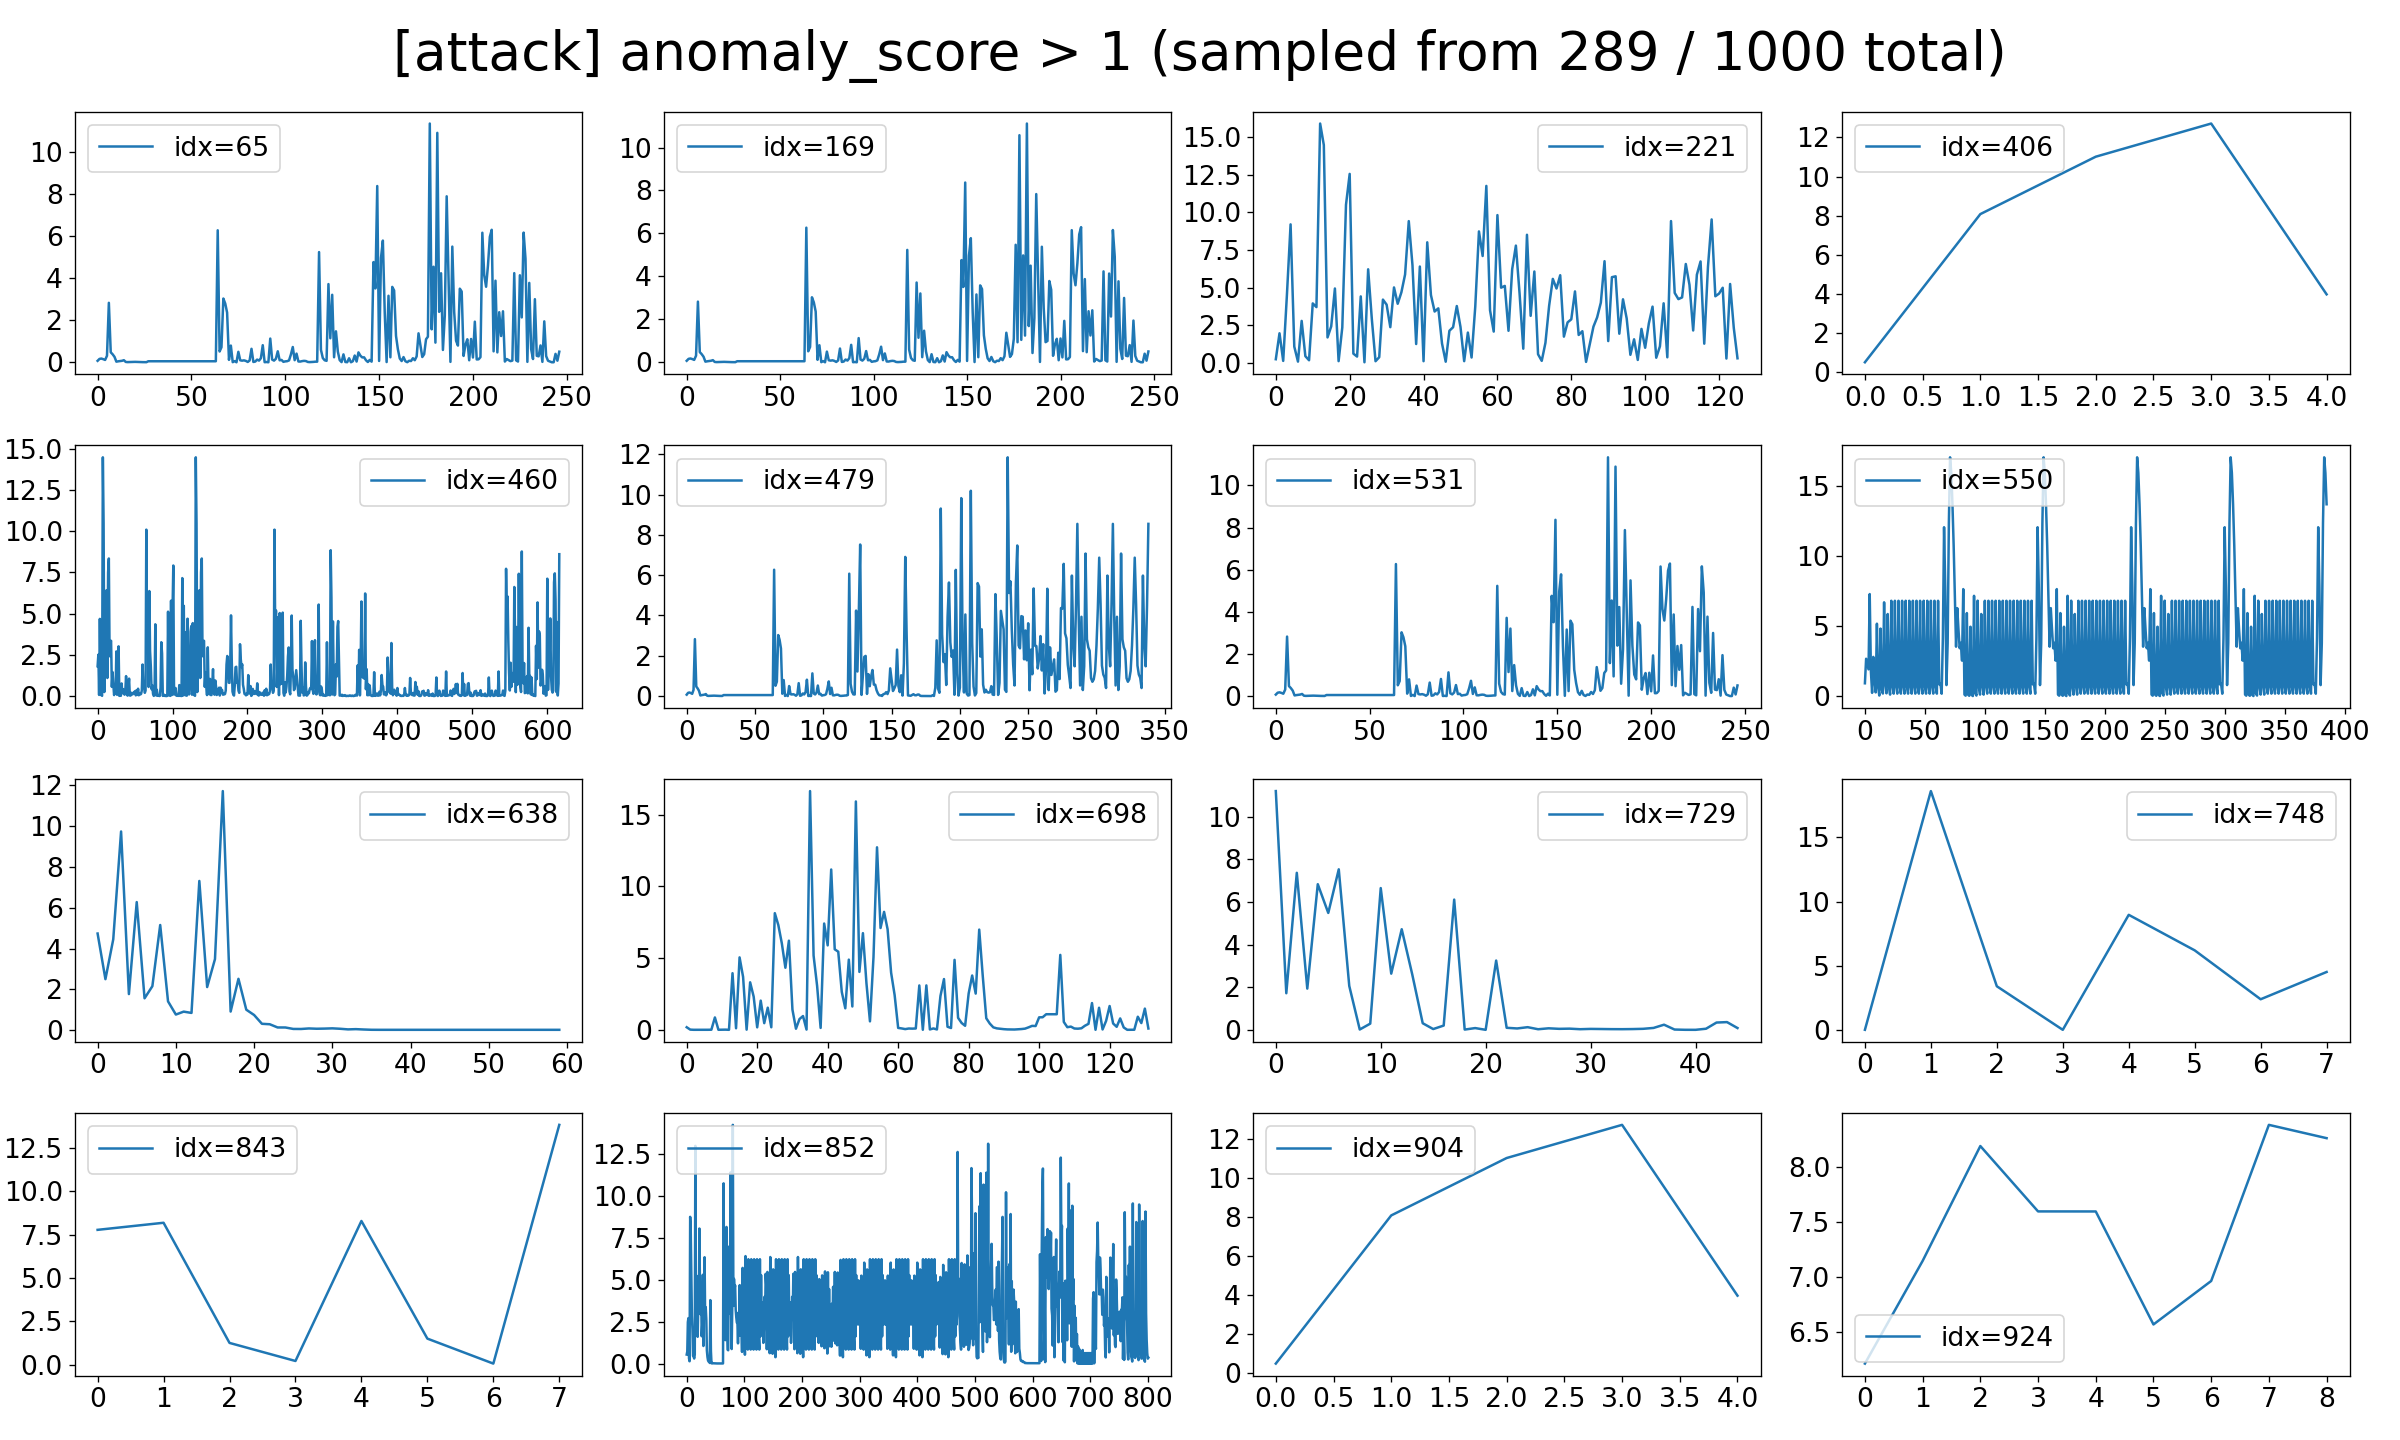

In [25]:
do_high = True
do_save = True

plt.figure("samples-fcn0_0", figsize=((20, 12) if do_save else (10,6)))



thresh = 1
if do_high:
    bounds_args = (thresh, None)
else:
    bounds_args = (None, thresh)

if do_save:
    rc_params = {'font.size': 16}
    title_kwargs = {'fontsize' : 32}
else:
    rc_params = {}
    title_kwargs = {}
    
with plt.rc_context(rc_params):

    plot_sampled_step_likelihoods(
        *bounds_args,
    #     slug=f"{trace_type}] [{model_type}",
        slug=f"{trace_type}",
        title_kwargs=title_kwargs,
    )


    plots_dir = Path("results/eval_steps/plots")
    fname = f"sampled-plots_windows_{model_type}_{trace_type}_anom-score-{'gt' if do_high else 'lt'}-{thresh}.pdf"
    if do_save:
        plt.savefig(plots_dir / fname)

    plt.show()

In [17]:
# plt.figure("samples-fcn-delta", figsize=(10, 6))

# delta = 0.2

# plot_sampled_step_likelihoods(
# #     None, 1,
# #     1, None,
#     1-delta, 1+delta,
#     slug=f"{trace_type}] [{model_type}",
# )
# plt.show()

In [18]:
if trace_type == "attack":
    thresh_low = 0.18
    thresh_high = 0.32
elif trace_type == "test":
    thresh_low = 0.62
    thresh_high = 0.64
else:
    raise ValueError()
mask = np.array([thresh_low < np.mean(arr) < thresh_high for arr in likelihoods])
inds = np.arange(len(mask))[mask]
fnames_local = [fnames[ind] for ind in inds]

seqs_local = []
for fpath0 in fnames_local:
    if fpath0.startswith("/workspace"):
        fpath = fpath0.replace("/workspace", "..")
    else:
        fpath = fpath0
        
    with open(fpath, "r") as f:
        for line in f:
            break
        line = line.strip()
        seq = [int(x) for x in line.split()]
    seqs_local.append(seq)

In [19]:
len(inds)

37

In [20]:
[np.array(x) for x in seqs_local];

In [21]:
# ind = 0
# while True:
#     n = 0
#     vals = []
#     for seq in seqs_local:
#         if ind >= len(seq):
#             val = ""
#         else:
#             val = seq[ind]
#             n += 1
#         val = str(val)
#         val = val.rjust(3)
#         vals.append(val)
#     if n == 0:
#         break
#     ind += 1
    
#     print(*vals)
        

In [22]:
doWrite = False
if doWrite:
#     with open("results_firstAttackPeak.txt", 'w') as fout:
    with open("results_hugeBenignPeak.txt", 'w') as fout:
        for seq in seqs_local:
            print(*seq, file=fout)

In [23]:
fnames_local_short = [f"{Path(f).parent.name} / {Path(f).name}" for f in fnames_local]
sorted(fnames_local_short)

['attack / 00d7bcafe9e33ede2af6cf91cc33e176_1920_2300.txt',
 'attack / 01a9d166e6f35c7fb1c59c5c6477f4c7_1324_3292.txt',
 'attack / 0a099f3c2787f487dc787c206a976b3f_1280_1416.txt',
 'attack / 0a58cbdbfce0d96313e1a2448b665338_1280_1368.txt',
 'attack / 0a7aca58836451c4f7843c43f4981d7f_3224_3200.txt',
 'attack / 0a7f548b4cf67418fa7add5b82e0e1bd_1124_2932.txt',
 'attack / 0a7f548b4cf67418fa7add5b82e0e1bd_2876_2576.txt',
 'attack / 0b52bc21d0a11b296800fcb47a346f10_2256_3396.txt',
 'attack / 0c9256704d5435ded461020b0dae6425_1280_1416.txt',
 'attack / 0cefbf1386781ea858485b4ccc390920_4240_4276.txt',
 'attack / 0cf053cfd40eeae31ec034d793ec5f90_1280_1368.txt',
 'attack / 0d40e52b0cd3ff004a94ed31eb1c4f13_2664_2992.txt',
 'attack / 0d63238eb8bf19e8a3227c284f8daa0d_1280_1284.txt',
 'attack / 0eaa26ace977f5a35b6ebfb1c5f145a8_640_2724.txt',
 'attack / 0eae2987f480188e00ae8e82bc6c09d0_2660_3252.txt',
 'attack / 0f069a45bc5ff0a137c7463f3a88408d_3232_2992.txt',
 'attack / 133_1280_2108.txt',
 'attack /

In [24]:
fnames_short = [f"{Path(f).parent.name} / {Path(f).name}" for f in fnames]
sorted(fnames_short);